# Exploratory Data Analysis (EDA)

This notebook performs initial data exploration on the raw heart disease dataset. It inspects data shape, missing values, distributions, and target balance.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("../data/raw/heart.csv")
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")
df.head()

Loaded dataset with 1025 rows and 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# Basic dataset information
print("Columns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())
print("\nSummary statistics:")
print(df.describe(include="all").T)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Summary statistics:
           count        mean        std    min    25%    50%    75%    max
age       1025.0   54.434146   9.072290   29.0   48.0   56.0   61.0   77.0
sex       1025.0    0.695610   0.460373    0.0    0.0    1.0    1.0    1.0
cp        1025.0    0.942439   1.029641    0.0    0.0    1.0    2.0    3.0
trestbps  1025

target
0    499
1    526
Name: count, dtype: int64


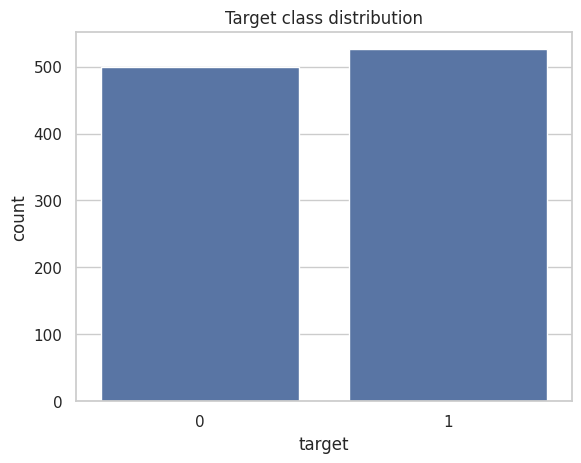

In [3]:
# Target balance and class distribution
if "target" in df.columns:
    target_counts = df["target"].value_counts().sort_index()
    print(target_counts)
    sns.barplot(x=target_counts.index, y=target_counts.values)
    plt.title("Target class distribution")
    plt.xlabel("target")
    plt.ylabel("count")
    plt.show()
else:
    print("No 'target' column found in dataset.")

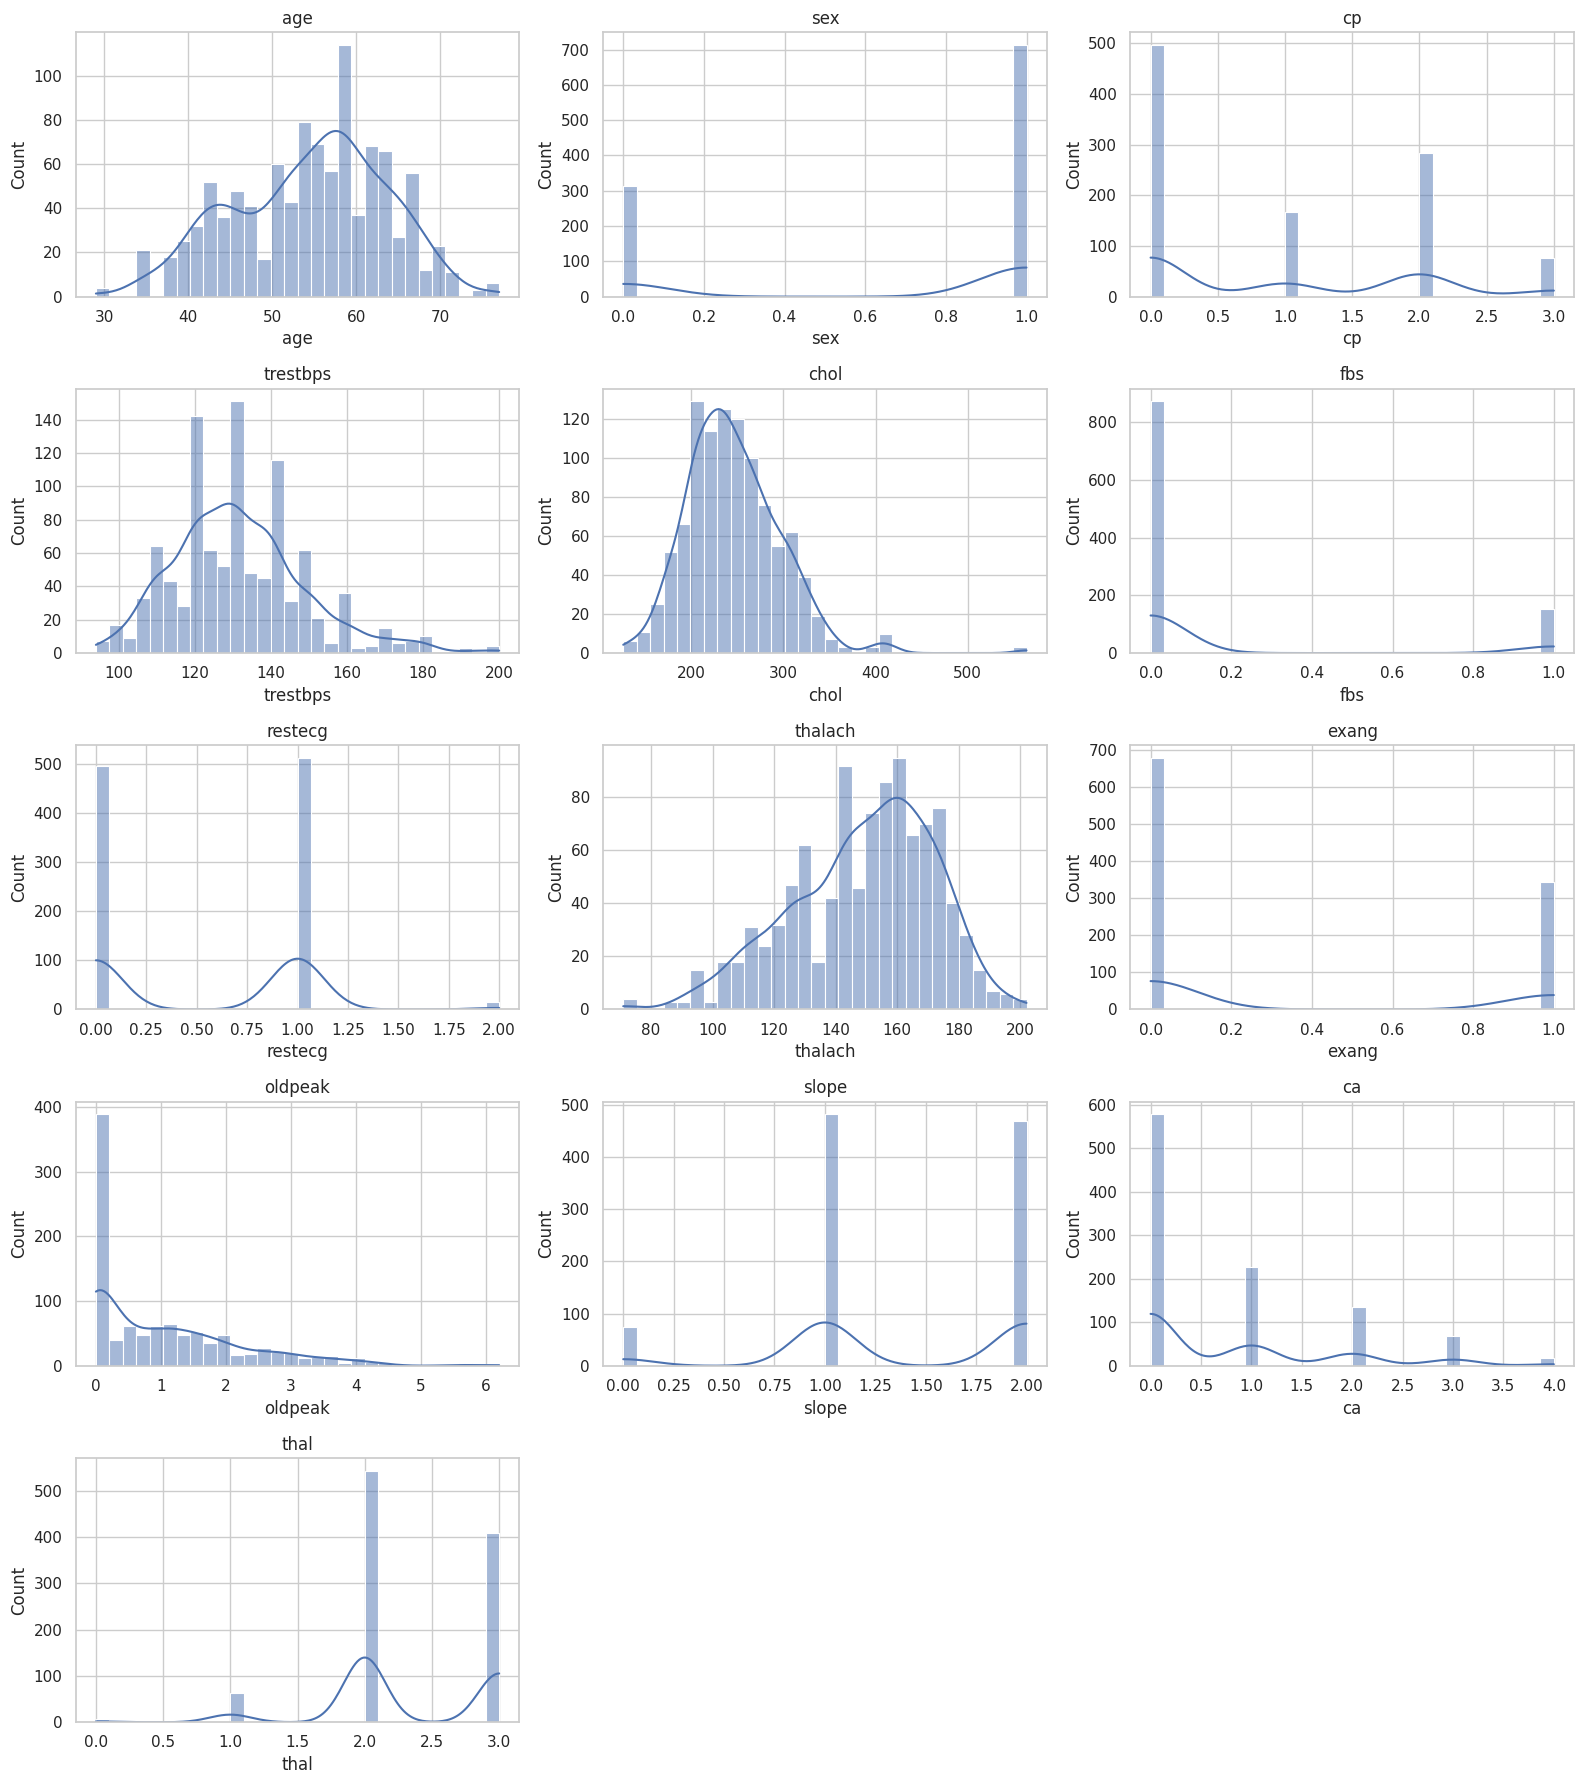

In [4]:
# Visualize numeric feature distributions
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if "target" in numeric_features:
    numeric_features.remove("target")

fig, axes = plt.subplots(len(numeric_features) // 3 + 1, 3, figsize=(16, 18))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## Findings and next steps

### Continuous / wide-range features
- `age`: 29–77, median 56, IQR 48–61
- `trestbps` (resting blood pressure): 94–200, median 130
- `chol` (cholesterol): 126–564, median 240
- `thalach` (max heart rate): 71–202, median 152
- `oldpeak` (ST depression): 0.0–6.2, median 0.8

These have broad ranges and will likely benefit from scaling for ML models.

### Binary / near-binary features
- `sex`: 0 = 312, 1 = 713
- `fbs` (fasting blood sugar > 120 mg/dl): 0 = 872, 1 = 153
- `exang` (exercise-induced angina): 0 = 680, 1 = 345

These can safely be treated as categorical/binary features.

### Multi-class categorical-like features
- `cp` (chest pain type): 0 = 497, 1 = 167, 2 = 284, 3 = 77
- `restecg`: 0 = 497, 1 = 513, 2 = 15
- `slope`: 0 = 74, 1 = 482, 2 = 469
- `ca` (number of major vessels): 0 = 578, 1 = 226, 2 = 134, 3 = 69, 4 = 18
- `thal`: 0 = 7, 1 = 64, 2 = 544, 3 = 410

These are categorical ordinal or nominal variables; one-hot or ordinal encoding is appropriate depending on the model.

### Target
- `target`: 0 = 499, 1 = 526

The class balance is nearly even, so no strong imbalance correction is required initially.

## So let's do:
- Scale continuous variables (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`)
- Encode binary and categorical features explicitly
- Keep `target` as the binary label for baseline modeling

Next update data_preprocessing.py to implement this preprocessing and save cleaned data.